In [1]:
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import plot_utils, decoding_utils, encoding_utils, io_utils
from statsmodels.stats.multitest import fdrcorrection

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook

In [2]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('is_ephys'),
    pl.col('is_opto_perturbation').eq(False),
    pl.col('is_injection_perturbation').eq(False),
    pl.col('is_context_naive').eq(False),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

In [3]:
savepath=r"C:\Users\shailaja.akella\Dropbox (Personal)\DR\figure_final_pdfs\version2\figure2"

In [ ]:
def get_wide_table(result_prefix, run_id): 
    return pl.scan_parquet(f"s3://aind-scratch-data/dynamic-routing/encoding/scores/{result_prefix}_{run_id}.parquet",  storage_options={"skip_signature": "true"},).collect()

def add_unit_metrics(unit_df):
    return (
        unit_df.lazy()
                .join(
            pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.289/consolidated/units.parquet', storage_options={"skip_signature": "true"})
            # " THIS NEEDS TO GOOOOO!!!! ITS JUST WRONG!!! FORBIDDENNN!! " - Ben Hardcastle
            .select('unit_id','structure','location','activity_drift','isi_violations_ratio',
                    'presence_ratio', 'amplitude_cutoff','firing_rate', 'decoder_label'),# right table
            on='unit_id',
            how = 'inner',
        ) 
    ).collect()

def get_model_weights_from_s3(unit_ids, result_prefix, run_id):
    
    parquet_path = f's3://aind-scratch-data/dynamic-routing/encoding/results/{result_prefix}_{run_id}/'
    return  (
            pl.scan_parquet(parquet_path, storage_options={"skip_signature": "true"})# left table
            .filter(
                (pl.col("unit_id").is_in(unit_ids))
                & (
                    (pl.col("model_label") == "fullmodel")
                    | ((pl.col("model_label") == "drop") & (pl.col("dropped_variable") == "context"))
                )
                )
            .select(["unit_id", "model_label", "dropped_variable", "weights"])
            ).collect()


In [30]:
savepath=r"C:\Users\shailaja.akella\Dropbox (Personal)\DR\figure_final_pdfs\version2\figure2"

In [22]:
#glm baseline results
result_prefix = 'v289'
run_id = "3"

glm_baseline_results = get_wide_table(result_prefix= result_prefix, run_id = run_id)
glm_baseline_results = add_unit_metrics(glm_baseline_results)

structure_mapping = {
    "ECT1": 'ECT',
    "ECT2/3": 'ECT',
    "ECT6b": 'ECT',
    "ECT5": 'ECT',
    "ECT6a": 'ECT',
    "ECT4": 'ECT',
    'SCop': 'SCs',
    'SCsg': 'SCs',
    'SCzo': 'SCs',
    'SCig': 'SCm',
    'SCiw': 'SCm',
    'SCdg': 'SCm',
    'SCdw': 'SCm',
}

# map SC units to SCs or SCm, also ECT (maybe not necessary?)
glm_baseline_results = glm_baseline_results.with_columns(
    pl.when(pl.col('structure').is_in(structure_mapping.keys()).is_first_distinct().over('unit_id'))
    .then(pl.col('structure').replace(structure_mapping))
    .otherwise(pl.col('structure'))
)

# exclude redundant or general structures
glm_baseline_results = decoding_utils.exclude_structures_from_df(
    glm_baseline_results, exclude_redundant_structures=True, exclude_general_structures=True
).to_pandas()

glm_baseline_results=glm_baseline_results.query(
    'session_id in @dr_session_list and \
    presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.1'
    )
glm_baseline_results['mouse_id']=glm_baseline_results['session_id'].str.split('_').str[0]
glm_baseline_results.columns

Index(['session_id', 'unit_id', 'project', 'cv_test_running',
       'cv_test_context', 'cv_test_session_time', 'cv_test_nose',
       'cv_test_jaw', 'cv_test_ears', 'cv_test_whisker_pad',
       'cv_test_facial_features', 'cv_test_pupil', 'cv_train_running',
       'cv_train_context', 'cv_train_session_time', 'cv_train_nose',
       'cv_train_jaw', 'cv_train_ears', 'cv_train_whisker_pad',
       'cv_train_facial_features', 'cv_train_pupil', 'drop_score_running',
       'drop_score_context', 'drop_score_session_time', 'drop_score_nose',
       'drop_score_jaw', 'drop_score_ears', 'drop_score_whisker_pad',
       'drop_score_facial_features', 'drop_score_pupil', 'delta_r2_running',
       'delta_r2_context', 'delta_r2_session_time', 'delta_r2_nose',
       'delta_r2_jaw', 'delta_r2_ears', 'delta_r2_whisker_pad',
       'delta_r2_facial_features', 'delta_r2_pupil', 'cv_test_fullmodel',
       'cv_train_fullmodel', 'cv_test_shifts', 'shift_indexes',
       'drop_score_linear_shift', 'delt

In [84]:
# pick units with high delta_r2_context and from area to plot

thresh_score = 0.05
thresh_r2 = 0.1
area_to_plot_from = 'MOs'

high_delta_r2 = glm_baseline_results.query('drop_score_context > @thresh_score and structure == @area_to_plot_from and cv_test_fullmodel > @thresh_r2')

# Pick the session with the highest mean delta_r2_context among selected units.
session_mean_delta_r2 = high_delta_r2.groupby('session_id')['delta_r2_context'].mean()
if session_mean_delta_r2.empty:
    raise ValueError(f'No {area_to_plot_from} units have delta_r2_context > {thresh_score}')
session_to_plot = session_mean_delta_r2.idxmax()
print(f'Session to plot: {session_to_plot}')

# Pick units from that session.
units_to_plot = high_delta_r2.query('session_id == @session_to_plot')['unit_id'].tolist()


# get fullmodel and drop_context weights for the units to plot
weights = get_model_weights_from_s3(units_to_plot, result_prefix, run_id)

Session to plot: 644867_2023-02-23


In [85]:
import dr_datacube
from dynamic_routing_analysis import encoding_utils, io_utils

# Build the design matrix for the selected session using the encoding pipeline settings.
# Params.__init__ parses Jupyter kernel arguments; model_construct uses class defaults instead.
params = encoding_utils.Params.model_construct(
    result_prefix=result_prefix,
    run_id=run_id,
    time_of_interest='quiescent',
    spike_bin_width=0.1,
    orthogonalize_against_context=['facial_features'],
)

project = session_table.filter(pl.col('session_id') == session_to_plot).select('project').item()
run_params = params.model_dump()
run_params.update(fullmodel_fitted=False, model_label='fullmodel', project=project)
run_params = io_utils.define_kernels(run_params)

# Use the public scratch cache; the default Code Ocean asset denies anonymous listing.
with dr_datacube.config.override(anon=True, use_cache=True):
    _, behavior_info = io_utils.get_session_data(session_to_plot, lazy=True)
    fit = io_utils.establish_timebins(run_params, {}, behavior_info)
    design = io_utils.DesignMatrix(fit)
    design, fit = io_utils.add_kernels(
        design=design,
        run_params=run_params,
        session=session_to_plot,
        fit=fit,
        behavior_info=behavior_info,
    )
    if fit['failed_kernels']:
        raise RuntimeError(f"Failed to build kernels: {sorted(fit['failed_kernels'])}")

feature_mat = design.get_X()  # dimensions: timestamps x weights
feature_mat


Fetching `units` includes spike times and can be slow. Setting `infer_schema_length=1` for faster inference: set it to `None` to disable this optimization.
Use `get_lf('unit_metrics')` for the consolidated units table without spike times.


<xarray.DataArray (timestamps: 7518, weights: 63)> Size: 4MB
array([[-2.13935883, -2.72572858, -0.88350948, ..., -1.        ,
        -1.72429567,  1.        ],
       [-2.09906835, -2.13935883, -2.72572858, ..., -1.        ,
        -1.72420054,  1.        ],
       [-2.17051547, -2.09906835, -2.13935883, ..., -1.        ,
        -1.72410542,  1.        ],
       ...,
       [-1.71589089, -1.61307931, -1.51534739, ...,  1.        ,
         1.73562552,  1.        ],
       [-1.22317353, -1.71589089, -1.61307931, ...,  1.        ,
         1.73572065,  1.        ],
       [-4.08305121, -1.22317353, -1.71589089, ...,  1.        ,
         1.73581577,  1.        ]])
Coordinates:
  * timestamps  (timestamps) float64 60kB 1.166e+03 1.166e+03 ... 4.803e+03
  * weights     (weights) <U14 4kB 'ears_-5' 'ears_-4' ... 'intercept_0'

In [86]:
# Reconstruct predicted spike counts per 0.1 s bin for each selected unit.
# The drop_context model was fitted after removing context columns from the full design matrix.
drop_context_labels = [
    label for label in feature_mat.weights.values
    if label.rsplit('_', 1)[0] != 'context'
]
model_designs = {
    'fullmodel': feature_mat,
    'drop_context': feature_mat.sel(weights=drop_context_labels),
}

predictions = {}
for row in weights.iter_rows(named=True):
    model = 'drop_context' if row['model_label'] == 'drop' else 'fullmodel'
    design_for_model = model_designs[model]
    coefficients = np.asarray(row['weights'], dtype=float)
    if coefficients.size != design_for_model.sizes['weights']:
        raise ValueError(
            f"{row['unit_id']} {model}: {coefficients.size} coefficients for "
            f"{design_for_model.sizes['weights']} design-matrix columns"
        )
    key = (row['unit_id'], model)
    if key in predictions:
        raise ValueError(f"Duplicate weights for {key}")
    predictions[key] = design_for_model.data @ coefficients

if not predictions:
    raise ValueError('No model weights were found for the selected units')

predicted_activity = pd.DataFrame(
    predictions,
    index=pd.Index(feature_mat.timestamps.values, name='timestamp'),
)
predicted_activity.columns = pd.MultiIndex.from_tuples(
    predicted_activity.columns, names=['unit_id', 'model']
)
predicted_activity


unit_id,644867_2023-02-23_A-26,644867_2023-02-23_A-90,644867_2023-02-23_A-26,644867_2023-02-23_A-90
model,drop_context,drop_context,fullmodel,fullmodel
timestamp,,,,
1166.020075,1.731800,1.228387,1.982237,1.275204
1166.120075,1.849851,1.492189,2.192903,1.556320
1166.220075,1.608153,1.121797,1.858441,1.168586
1166.320075,1.609457,1.431180,1.886384,1.482949
1166.420075,1.284253,0.893119,1.619073,0.955712
...,...,...,...,...
4803.046090,0.776345,2.080369,0.674425,2.061316
4803.146090,1.030985,2.319907,0.905932,2.296529


Saved figure for unit 644867_2023-02-23_A-26 in area MOs


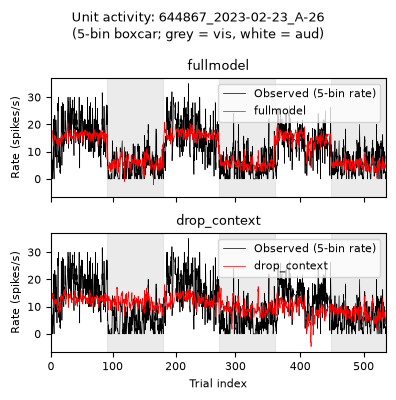

In [95]:
unit_id_to_plot = units_to_plot[1]
if unit_id_to_plot not in predicted_activity.columns.get_level_values('unit_id'):
    raise KeyError(f'{unit_id_to_plot} has no reconstructed activity in predicted_activity')

# Read this unit's spike times from the same versioned cache used for feature_mat.
with dr_datacube.config.override(anon=True, use_cache=True):
    unit_row = (
        dr_datacube.get_lf(
            'units', session_id=session_to_plot, nwb=False, only_in_data_asset=False
        )
        .filter(pl.col('unit_id') == unit_id_to_plot)
        .select('spike_times')
        .collect()
    )
if unit_row.height != 1 or 'spike_times' not in unit_row.columns:
    raise ValueError(f'Expected spike times for one unit: {unit_id_to_plot}')
if unit_row['spike_times'][0] is None:
    raise ValueError(f'Spike times are missing for {unit_id_to_plot}')

spike_times = np.sort(np.asarray(unit_row['spike_times'][0], dtype=float))
np.testing.assert_allclose(feature_mat.timestamps.values, fit['bin_centers'])
true_activity = pd.Series(
    io_utils.get_spike_counts(spike_times, fit['timebins']),
    index=pd.Index(feature_mat.timestamps.values, name='timestamp'),
    name='observed',
)

def boxcar_rate(counts, epoch_trace, bin_width, window=10):
    """Average counts within each trial, then convert to spikes per second."""
    rates = np.empty(len(counts), dtype=float)
    epoch_trace = np.asarray(epoch_trace)
    for epoch in pd.unique(epoch_trace):
        mask = epoch_trace == epoch
        trial_counts = np.asarray(counts)[mask]
        rates[mask] = (
            pd.Series(trial_counts).rolling(window, center=True, min_periods=1).mean()
            .to_numpy() / bin_width
        )
    return rates

bin_width = run_params['spike_bin_width']
true_rate = pd.Series(
    boxcar_rate(true_activity.to_numpy(), fit['epoch_trace'], bin_width),
    index=true_activity.index, name='observed_rate_hz',
)
unit_activity = predicted_activity.xs(unit_id_to_plot, axis='columns', level='unit_id')
predicted_rates = pd.DataFrame(
    {model: boxcar_rate(unit_activity[model].to_numpy(), fit['epoch_trace'], bin_width)
     for model in unit_activity.columns},
    index=unit_activity.index,
)

# Shade complete visual-context blocks, including gaps between quiescent trial bins.
trials = behavior_info['trials'].sort_values('stim_start_time').reset_index(drop=True)
modalities = trials['rewarded_modality'].astype(str).str.lower().to_numpy()
block_starts = trials['stim_start_time'].to_numpy() + run_params['quiescent_start_time']
change_indices = np.r_[0, np.flatnonzero(modalities[1:] != modalities[:-1]) + 1]

required_models = {'fullmodel', 'drop_context'}
missing_models = required_models - set(predicted_rates.columns)
if missing_models:
    raise ValueError(f'Missing predicted activity for: {sorted(missing_models)}')

fig, (ax_full, ax_drop) = plt.subplots(2, 1, figsize=(4, 4), sharex=True, sharey=True)
for block_no, start_idx in enumerate(change_indices):
    if modalities[start_idx] != 'vis':
        continue
    end = (block_starts[change_indices[block_no + 1]]
           if block_no + 1 < len(change_indices) else fit['timebins'][-1, 1])
    for ax in (ax_full, ax_drop):
        ax.axvspan(block_starts[start_idx], end, color='0.85', alpha=0.5, zorder=0)

for ax, model in ((ax_full, 'fullmodel'), (ax_drop, 'drop_context')):
    ax.plot(true_rate.index, true_rate.values, color='black', linewidth=0.5,
            label='Observed (5-bin rate)')
    ax.plot(predicted_rates.index, predicted_rates[model], color='red',
            linewidth=0.5, label=model)
    ax.set(ylabel='Rate (spikes/s)', title=model)
    ax.legend()

# Keep the time axis, but put its ticks at trial-window centers and label trial indices.
trial_centers = trials['stim_start_time'].to_numpy() + (
    run_params['quiescent_start_time'] + run_params['quiescent_stop_time']
) / 2
trial_indices = (trials['trial_index'].to_numpy()
                 if 'trial_index' in trials.columns else np.arange(len(trials)))
tick_indices = np.flatnonzero(trial_indices % 100 == 0)
ax_drop.set_xticks(trial_centers[tick_indices])
ax_drop.set_xticklabels(trial_indices[tick_indices])
ax_drop.set_xlabel('Trial index')
ax_drop.set_xlim(fit['timebins'][0, 0], fit['timebins'][-1, 1])
fig.suptitle(f'Unit activity: {unit_id_to_plot}\n(5-bin boxcar; grey = vis, white = aud)')
fig.tight_layout()


plt.savefig(os.path.join(savepath,f"unit_{unit_id_to_plot}_{area_to_plot_from}.pdf"),dpi=600,bbox_inches='tight')
print(f'Saved figure for unit {unit_id_to_plot} in area {area_to_plot_from}')

In [27]:
session_id_to_check = session_to_plot
other_area_counts = (
    glm_baseline_results.loc[glm_baseline_results['session_id'] == session_id_to_check]
    .groupby('structure')['unit_id']
    .nunique()
    .drop('SCm', errors='ignore')
    .sort_values(ascending=False)
    .rename('n_units')
    .to_frame()
)
other_area_counts


,n_units
structure,
SSs,407
SSp,390
CP,220
PAR,86
MOp,77
VISpl,63
MOs,49
VISp,47
VISC,23
